### 1. Imports

In [1]:
import os
import re
import html
import json
import time
import joblib
import warnings
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import emoji
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "emoji"])
    import emoji

from google.colab import drive

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


### 2. Mount Google Drive + File path

In [2]:
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/Sentimental Analysis"

DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")
MODEL_RESULTS_DIR = os.path.join(PROJECT_DIR, "model_results")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")

os.makedirs(MODEL_RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(PROJECT_DIR, "train.csv")
VAL_PATH   = os.path.join(PROJECT_DIR, "val.csv")
TEST_PATH  = os.path.join(PROJECT_DIR, "test.csv")

COMBINED_TEST_PATH = os.path.join(DATASET_DIR, "mental_health_combined_test.csv")
UNBALANCED_PATH    = os.path.join(DATASET_DIR, "mental_heath_unbanlanced.csv")

print("PROJECT_DIR:", PROJECT_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("MODEL_RESULTS_DIR:", MODEL_RESULTS_DIR)
print("MODELS_DIR:", MODELS_DIR)

print("\nChecking files:")
for path in [
    TRAIN_PATH,
    VAL_PATH,
    TEST_PATH,
    COMBINED_TEST_PATH,
    UNBALANCED_PATH
]:
    print(os.path.exists(path), "->", path)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/Sentimental Analysis
DATASET_DIR: /content/drive/MyDrive/Sentimental Analysis/dataset
MODEL_RESULTS_DIR: /content/drive/MyDrive/Sentimental Analysis/model_results
MODELS_DIR: /content/drive/MyDrive/Sentimental Analysis/models

Checking files:
True -> /content/drive/MyDrive/Sentimental Analysis/train.csv
True -> /content/drive/MyDrive/Sentimental Analysis/val.csv
True -> /content/drive/MyDrive/Sentimental Analysis/test.csv
True -> /content/drive/MyDrive/Sentimental Analysis/dataset/mental_health_combined_test.csv
True -> /content/drive/MyDrive/Sentimental Analysis/dataset/mental_heath_unbanlanced.csv


### 3. Load train, validation, test

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:", train_df.columns.tolist())

display(train_df.head())

Train shape: (34601, 2)
Val shape: (4943, 2)
Test shape: (9887, 2)

Columns: ['text', 'status']


,text,status
0,Is anime bad ? Is anime bad ? I think it’s bad...,normal
1,horror wench me toooooo i feel like i ve been ...,normal
2,Context: My father-in-law is/was the ultimate ...,normal
3,Been trying the whole online dating thing have...,suicidal
4,á¨³ â™¡ Selling passive Caucasian Instagram fo...,normal


### 4. Text & label columns

In [4]:
def infer_columns(df):
    possible_text_cols = [
        "text", "Text", "clean_text", "sentence", "content",
        "statement", "review", "message"
    ]

    possible_label_cols = [
        "label", "Label", "target", "class", "category",
        "status", "sentiment"
    ]

    text_col = None
    label_col = None

    for col in possible_text_cols:
        if col in df.columns:
            text_col = col
            break

    for col in possible_label_cols:
        if col in df.columns:
            label_col = col
            break

    if text_col is None:
        object_cols = df.select_dtypes(include=["object"]).columns.tolist()
        text_col = object_cols[0]

    if label_col is None:
        candidate_cols = [c for c in df.columns if c != text_col]
        label_col = candidate_cols[0]

    return text_col, label_col


TEXT_COL, LABEL_COL = infer_columns(train_df)

print("TEXT_COL:", TEXT_COL)
print("LABEL_COL:", LABEL_COL)

print("\nTrain class distribution:")
display(train_df[LABEL_COL].value_counts())

print("\nValidation class distribution:")
display(val_df[LABEL_COL].value_counts())

print("\nTest class distribution:")
display(test_df[LABEL_COL].value_counts())

TEXT_COL: text
LABEL_COL: status

Train class distribution:


,count
status,
normal,12706
depression,10154
suicidal,7840
anxiety,3901



Validation class distribution:


,count
status,
normal,1815
depression,1451
suicidal,1120
anxiety,557



Test class distribution:


,count
status,
normal,3630
depression,2902
suicidal,2240
anxiety,1115


### 5. Clean text: emoji + special tag normalization


In [5]:
def clean_text_for_ml(text):
    """
    Clean text for traditional ML models.

    Main design choices:
    - Emoji are converted to English description tokens.
      Example: 😊 -> emoji_smiling_face_with_smiling_eyes
    - @mentions are normalized to username_token.
    - URLs are normalized to url_token.
    - Dataset tags such as <username>, <url>, <name>, <number>
      are normalized to stable tokens.
    - Real numbers are normalized to number_token.
    """
    if pd.isna(text):
        return ""

    text = str(text)
    text = html.unescape(text)

    # Convert emoji to English alias.
    # Example: 😊 -> :smiling_face_with_smiling_eyes:
    try:
        text = emoji.demojize(text, language="en")
    except TypeError:
        text = emoji.demojize(text)

    # Convert :emoji_name: into a TF-IDF friendly token.
    # Example: :face_with_tears_of_joy: -> emoji_face_with_tears_of_joy
    text = re.sub(
        r":([a-zA-Z0-9_+\-]+):",
        lambda m: " emoji_" + m.group(1).lower() + " ",
        text
    )

    # Normalize common dataset tags before removing generic HTML tags.
    tag_map = {
        "<username>": " username_token ",
        "<user>": " username_token ",
        "<url>": " url_token ",
        "<link>": " url_token ",
        "<name>": " name_token ",
        "<number>": " number_token ",
        "<num>": " number_token "
    }

    for tag, replacement in tag_map.items():
        text = re.sub(re.escape(tag), replacement, text, flags=re.IGNORECASE)

    # Normalize real URLs.
    text = re.sub(r"https?://\S+|www\.\S+", " url_token ", text)

    # Normalize @mentions.
    text = re.sub(r"@\w+", " username_token ", text)

    # Remove remaining HTML/XML-like tags that are not meaningful.
    text = re.sub(r"<[^>]+>", " ", text)

    # Keep hashtag words, remove only #.
    text = re.sub(r"#(\w+)", r"\1", text)

    # Normalize numbers.
    text = re.sub(r"\b\d+([.,]\d+)?\b", " number_token ", text)

    # Normalize apostrophes.
    text = text.replace("’", "'").replace("`", "'").replace("´", "'")

    # Lowercase for traditional ML.
    text = text.lower()

    # Normalize repeated characters: sooooo -> soo
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Keep useful English characters, punctuation, and underscores for special tokens.
    text = re.sub(r"[^a-z0-9_\s\.\,\!\?\']", " ", text)

    # Normalize whitespace.
    text = re.sub(r"\s+", " ", text).strip()

    return text


for df in [train_df, val_df, test_df]:
    df["clean_text"] = df[TEXT_COL].apply(clean_text_for_ml)

display(train_df[[TEXT_COL, "clean_text", LABEL_COL]].head())


,text,clean_text,status
0,Is anime bad ? Is anime bad ? I think it’s bad...,is anime bad ? is anime bad ? i think it's bad...,normal
1,horror wench me toooooo i feel like i ve been ...,horror wench me too i feel like i ve been on t...,normal
2,Context: My father-in-law is/was the ultimate ...,context my father in law is was the ultimate h...,normal
3,Been trying the whole online dating thing have...,been trying the whole online dating thing have...,suicidal
4,á¨³ â™¡ Selling passive Caucasian Instagram fo...,emoji_trade_mark selling passive caucasian ins...,normal


### 6. Encode labels

In [6]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df[LABEL_COL])
y_val   = label_encoder.transform(val_df[LABEL_COL])
y_test  = label_encoder.transform(test_df[LABEL_COL])

class_names = label_encoder.classes_

print("Classes:")
for idx, name in enumerate(class_names):
    print(idx, "->", name)

Classes:
0 -> anxiety
1 -> depression
2 -> normal
3 -> suicidal


### 7. Handcrafted feature extractor

In [7]:
DEPRESSION_WORDS = {
    "depressed", "depression", "sad", "hopeless", "worthless", "empty",
    "tired", "lonely", "cry", "crying", "miserable", "numb", "pain",
    "hate", "failure", "lost", "alone", "guilt", "broken", "unhappy",
    "helpless", "dark", "sleep", "sleepless", "therapy", "medication"
}

SUICIDAL_WORDS = {
    "suicide", "suicidal", "kill", "die", "death", "dead", "end",
    "overdose", "hang", "jump", "cut", "selfharm", "self-harm",
    "goodbye", "worthless", "burden", "knife", "rope", "pills",
    "ending", "lifeless", "noose"
}

ANXIETY_WORDS = {
    "anxiety", "anxious", "panic", "worry", "worried", "fear",
    "scared", "nervous", "stress", "stressed", "breath", "breathing",
    "heart", "attack", "chest", "overthinking", "trembling",
    "shaking", "sweating", "phobia", "afraid", "uneasy"
}


class TextStatsExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []

        for text in X:
            text = "" if pd.isna(text) else str(text)
            words = text.split()

            char_count = len(text)
            word_count = len(words)
            unique_word_count = len(set(words))

            avg_word_len = np.mean([len(w) for w in words]) if words else 0

            exclamation_count = text.count("!")
            question_count = text.count("?")
            dot_count = text.count(".")
            comma_count = text.count(",")

            lexical_diversity = unique_word_count / word_count if word_count > 0 else 0

            dep_count = sum(1 for w in words if w in DEPRESSION_WORDS)
            sui_count = sum(1 for w in words if w in SUICIDAL_WORDS)
            anx_count = sum(1 for w in words if w in ANXIETY_WORDS)

            dep_ratio = dep_count / word_count if word_count > 0 else 0
            sui_ratio = sui_count / word_count if word_count > 0 else 0
            anx_ratio = anx_count / word_count if word_count > 0 else 0

            has_suicidal_phrase = int(
                ("kill myself" in text) or
                ("end my life" in text) or
                ("want to die" in text) or
                ("wanna die" in text) or
                ("i want die" in text)
            )

            has_panic_phrase = int(
                ("panic attack" in text) or
                ("anxiety attack" in text) or
                ("heart racing" in text) or
                ("chest pain" in text)
            )

            has_depression_phrase = int(
                ("feel hopeless" in text) or
                ("feel empty" in text) or
                ("feel worthless" in text) or
                ("no motivation" in text)
            )

            features.append([
                char_count,
                word_count,
                unique_word_count,
                avg_word_len,
                exclamation_count,
                question_count,
                dot_count,
                comma_count,
                lexical_diversity,
                dep_count,
                sui_count,
                anx_count,
                dep_ratio,
                sui_ratio,
                anx_ratio,
                has_suicidal_phrase,
                has_panic_phrase,
                has_depression_phrase
            ])

        return np.array(features, dtype=np.float32)

### 8. TF-IDF word + char + handcrafted features

In [8]:
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=80000,
    sublinear_tf=True,
    strip_accents="unicode",
    norm="l2"
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 4),
    min_df=5,
    max_df=0.95,
    max_features=30000,
    sublinear_tf=True,
    norm="l2"
)

stats_features = Pipeline([
    ("stats", TextStatsExtractor()),
    ("scaler", StandardScaler())
])

features = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf),
    ("stats", stats_features)
])

### 9. Fit-transform feature

In [9]:
X_train_text = train_df["clean_text"].values
X_val_text   = val_df["clean_text"].values
X_test_text  = test_df["clean_text"].values

print("Fitting TF-IDF and handcrafted features...")
X_train = features.fit_transform(X_train_text, y_train)
X_val   = features.transform(X_val_text)
X_test  = features.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

Fitting TF-IDF and handcrafted features...
X_train shape: (34601, 109855)
X_val shape: (4943, 109855)
X_test shape: (9887, 109855)


### 10. Evaluation function: classification report + inference time


In [10]:
def evaluate_model(model, X, y_true, dataset_name="Validation", save_report_path=None):
    start_infer = time.perf_counter()
    y_pred = model.predict(X)
    infer_time_total = time.perf_counter() - start_infer
    infer_time_avg = infer_time_total / X.shape[0]

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"===== {dataset_name} Result =====")
    print(f"Accuracy              : {acc:.5f}")
    print(f"Macro F1              : {macro_f1:.5f}")
    print(f"Weighted F1           : {weighted_f1:.5f}")
    print(f"Inference time total  : {infer_time_total:.4f} seconds")
    print(f"Avg inference time    : {infer_time_avg:.8f} seconds/sample")
    print()

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True
    )

    print(report_text)

    if save_report_path is not None:
        report_df = pd.DataFrame(report_dict).transpose()
        report_df.to_csv(save_report_path)
        print("Saved classification report to:", save_report_path)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "infer_time_total_sec": infer_time_total,
        "infer_time_avg_sec_per_sample": infer_time_avg,
        "classification_report": report_dict,
        "y_pred": y_pred
    }

### 11. Tune LinearSVC by validation macro F1 + timing


In [11]:
svc_results = []

C_VALUES = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0]

for C in C_VALUES:
    print("=" * 80)
    print(f"Training LinearSVC with C={C}")

    model = LinearSVC(
        C=C,
        class_weight="balanced",
        max_iter=5000,
        tol=1e-3,
        dual="auto",
        random_state=RANDOM_STATE
    )

    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start_train

    start_infer = time.perf_counter()
    val_pred = model.predict(X_val)
    infer_time_total = time.perf_counter() - start_infer
    infer_time_avg = infer_time_total / X_val.shape[0]

    val_acc = accuracy_score(y_val, val_pred)
    val_macro_f1 = f1_score(y_val, val_pred, average="macro")
    val_weighted_f1 = f1_score(y_val, val_pred, average="weighted")

    print(f"Val Accuracy       : {val_acc:.5f}")
    print(f"Val Macro F1       : {val_macro_f1:.5f}")
    print(f"Val Weighted F1    : {val_weighted_f1:.5f}")
    print(f"Training time      : {train_time:.4f} seconds")
    print(f"Avg inference time : {infer_time_avg:.8f} seconds/sample")

    svc_results.append({
        "C": C,
        "model": model,
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "train_time_sec": train_time,
        "val_infer_time_total_sec": infer_time_total,
        "val_infer_time_avg_sec_per_sample": infer_time_avg
    })

svc_results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "model"}
    for r in svc_results
]).sort_values("val_macro_f1", ascending=False)

display(svc_results_df)

Training LinearSVC with C=0.1
Val Accuracy       : 0.80558
Val Macro F1       : 0.79373
Val Weighted F1    : 0.80240
Training time      : 1117.5782 seconds
Avg inference time : 0.00001190 seconds/sample
Training LinearSVC with C=0.25
Val Accuracy       : 0.80862
Val Macro F1       : 0.79811
Val Weighted F1    : 0.80606
Training time      : 1052.0050 seconds
Avg inference time : 0.00000529 seconds/sample
Training LinearSVC with C=0.5
Val Accuracy       : 0.80842
Val Macro F1       : 0.79782
Val Weighted F1    : 0.80625
Training time      : 1002.3880 seconds
Avg inference time : 0.00000678 seconds/sample
Training LinearSVC with C=1.0
Val Accuracy       : 0.80275
Val Macro F1       : 0.79114
Val Weighted F1    : 0.80087
Training time      : 932.4095 seconds
Avg inference time : 0.00000717 seconds/sample
Training LinearSVC with C=2.0
Val Accuracy       : 0.79628
Val Macro F1       : 0.78385
Val Weighted F1    : 0.79463
Training time      : 882.2956 seconds
Avg inference time : 0.00000809 s

,C,val_accuracy,val_macro_f1,val_weighted_f1,train_time_sec,val_infer_time_total_sec,val_infer_time_avg_sec_per_sample
1,0.25,0.808618,0.798115,0.806056,1052.004951,0.026161,0.000005
2,0.50,0.808416,0.797817,0.806249,1002.387990,0.033499,0.000007
0,0.10,0.805584,0.793726,0.802400,1117.578209,0.058827,0.000012
3,1.00,0.802751,0.791142,0.800866,932.409541,0.035445,0.000007
4,2.00,0.796278,0.783846,0.794625,882.295565,0.039994,0.000008
5,5.00,0.791018,0.778366,0.789483,875.301066,0.032082,0.000006


### 12. Choose best model via validation macro F1

In [12]:
best_result = sorted(
    svc_results,
    key=lambda x: x["val_macro_f1"],
    reverse=True
)[0]

best_model = best_result["model"]

print("Best LinearSVC config:")
print("C:", best_result["C"])
print("Val Accuracy:", best_result["val_accuracy"])
print("Val Macro F1:", best_result["val_macro_f1"])
print("Val Weighted F1:", best_result["val_weighted_f1"])

Best LinearSVC config:
C: 0.25
Val Accuracy: 0.8086182480275137
Val Macro F1: 0.7981149246271275
Val Weighted F1: 0.8060555903989945


### 13. Evaluate detailed validation

In [13]:
val_metrics = evaluate_model(
    best_model,
    X_val,
    y_val,
    dataset_name="Validation",
    save_report_path=os.path.join(MODEL_RESULTS_DIR, "validation_classification_report.csv")
)


===== Validation Result =====
Accuracy              : 0.80862
Macro F1              : 0.79811
Weighted F1           : 0.80606
Inference time total  : 0.0276 seconds
Avg inference time    : 0.00000558 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.8256    0.8582    0.8415       557
  depression     0.7613    0.6988    0.7287      1451
      normal     0.8953    0.9521    0.9228      1815
    suicidal     0.7051    0.6937    0.6994      1120

    accuracy                         0.8086      4943
   macro avg     0.7968    0.8007    0.7981      4943
weighted avg     0.8050    0.8086    0.8061      4943

Saved classification report to: /content/drive/MyDrive/Sentimental Analysis/model_results/validation_classification_report.csv


### 14. Confusion Matrix validation

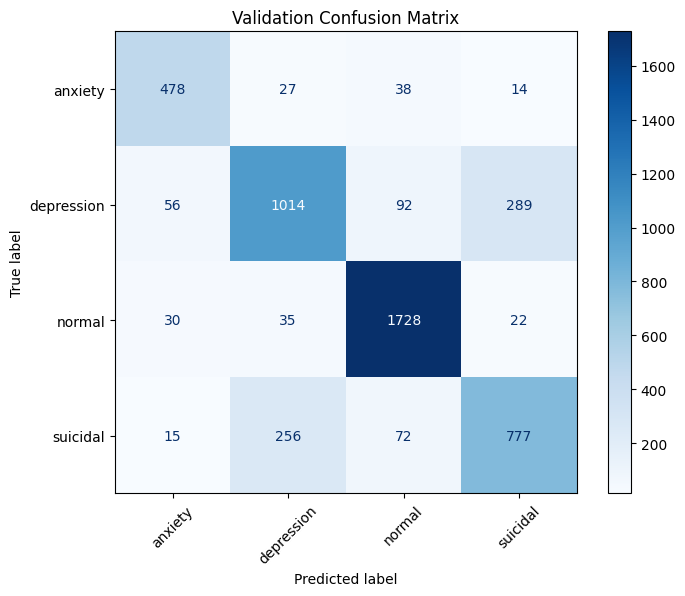

In [14]:
cm_val = confusion_matrix(y_val, val_metrics["y_pred"])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=class_names
)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
plt.title("Validation Confusion Matrix")
plt.show()

### 15. Evaluate test before retrain final

In [15]:
test_metrics = evaluate_model(
    best_model,
    X_test,
    y_test,
    dataset_name="Test before final retrain",
    save_report_path=os.path.join(MODEL_RESULTS_DIR, "test_classification_report_before_final.csv")
)


===== Test before final retrain Result =====
Accuracy              : 0.80216
Macro F1              : 0.78983
Weighted F1           : 0.80011
Inference time total  : 0.0971 seconds
Avg inference time    : 0.00000982 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.8038    0.8448    0.8238      1115
  depression     0.7446    0.6840    0.7130      2902
      normal     0.9072    0.9477    0.9270      3630
    suicidal     0.6930    0.6982    0.6956      2240

    accuracy                         0.8022      9887
   macro avg     0.7871    0.7937    0.7898      9887
weighted avg     0.7992    0.8022    0.8001      9887

Saved classification report to: /content/drive/MyDrive/Sentimental Analysis/model_results/test_classification_report_before_final.csv


### 16. Confusion matrix test before retrain final

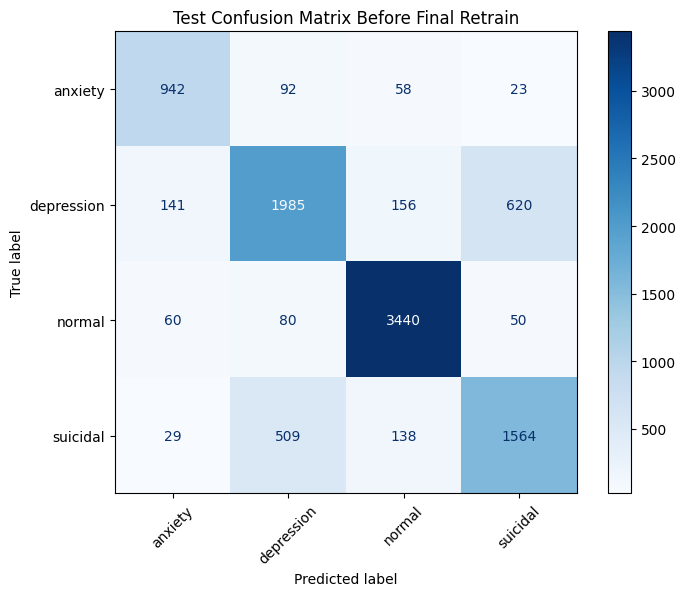

In [16]:
cm_test = confusion_matrix(y_test, test_metrics["y_pred"])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=class_names
)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
plt.title("Test Confusion Matrix Before Final Retrain")
plt.show()

### 17. Train final on train + validation

In [17]:
train_val_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

X_train_val_text = train_val_df["clean_text"].values
y_train_val = label_encoder.transform(train_val_df[LABEL_COL])

print("Refitting features on train + validation...")
X_train_val = features.fit_transform(X_train_val_text, y_train_val)
X_test_final = features.transform(X_test_text)

print("X_train_val shape:", X_train_val.shape)
print("X_test_final shape:", X_test_final.shape)

Refitting features on train + validation...
X_train_val shape: (39544, 110018)
X_test_final shape: (9887, 110018)


### 18. Create final LinearSVC with best C

In [18]:
final_model = LinearSVC(
    C=best_result["C"],
    class_weight="balanced",
    max_iter=5000,
    tol=1e-3,
    dual="auto",
    random_state=RANDOM_STATE
)

print(final_model)

LinearSVC(C=0.25, class_weight='balanced', max_iter=5000, random_state=42,
          tol=0.001)


### 19. Train final model

In [19]:
print("Training final LinearSVC on train + validation...")

start_final_train = time.perf_counter()
final_model.fit(X_train_val, y_train_val)
final_train_time = time.perf_counter() - start_final_train

print("Done.")
print(f"Final training time: {final_train_time:.4f} seconds")


Training final LinearSVC on train + validation...
Done.
Final training time: 1261.3664 seconds


### 20. Final test result

In [20]:
final_test_metrics = evaluate_model(
    final_model,
    X_test_final,
    y_test,
    dataset_name="Final Test",
    save_report_path=os.path.join(MODEL_RESULTS_DIR, "final_test_classification_report.csv")
)


===== Final Test Result =====
Accuracy              : 0.80409
Macro F1              : 0.79173
Weighted F1           : 0.80201
Inference time total  : 0.0449 seconds
Avg inference time    : 0.00000454 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.8029    0.8475    0.8246      1115
  depression     0.7510    0.6830    0.7154      2902
      normal     0.9077    0.9488    0.9278      3630
    suicidal     0.6935    0.7049    0.6991      2240

    accuracy                         0.8041      9887
   macro avg     0.7888    0.7960    0.7917      9887
weighted avg     0.8014    0.8041    0.8020      9887

Saved classification report to: /content/drive/MyDrive/Sentimental Analysis/model_results/final_test_classification_report.csv


### 21. Final confusion matrix

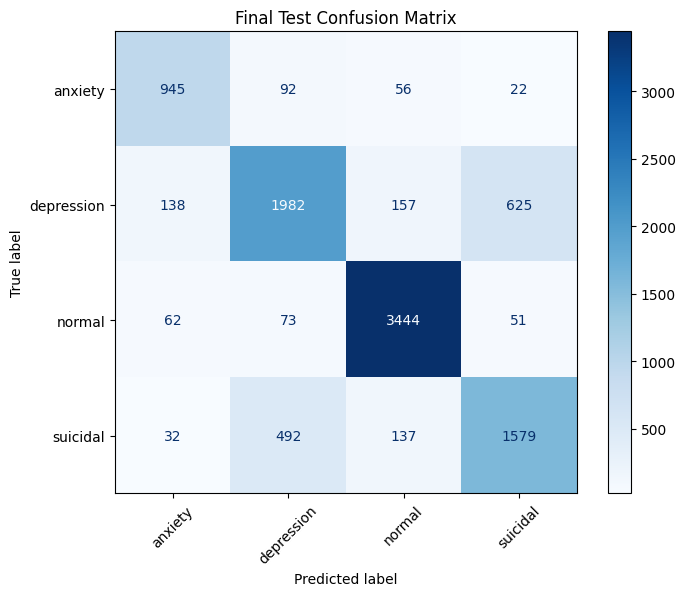

In [21]:
cm_final = confusion_matrix(y_test, final_test_metrics["y_pred"])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=class_names
)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
plt.title("Final Test Confusion Matrix")
plt.show()

### 22. Save model and result files


In [22]:
joblib.dump(features, os.path.join(MODELS_DIR, "tfidf_feature_extractor.joblib"))
joblib.dump(final_model, os.path.join(MODELS_DIR, "final_linearsvc_model.joblib"))
joblib.dump(label_encoder, os.path.join(MODELS_DIR, "label_encoder.joblib"))

best_config = {
    "model": "TF-IDF word + char + handcrafted features + LinearSVC",
    "optimization_metric": "validation_macro_f1",
    "preprocessing": {
        "emoji": "emoji converted to English tokens, e.g. emoji_smiling_face",
        "mentions": "@mention and <username> converted to username_token",
        "urls": "URL and <url> converted to url_token",
        "names": "<name> converted to name_token",
        "numbers": "numeric values and <number> converted to number_token"
    },
    "word_tfidf_max_features": 80000,
    "word_ngram_range": "(1, 2)",
    "char_tfidf_max_features": 30000,
    "char_ngram_range": "(3, 4)",
    "best_C": float(best_result["C"]),
    "validation_accuracy": float(best_result["val_accuracy"]),
    "validation_macro_f1": float(best_result["val_macro_f1"]),
    "validation_weighted_f1": float(best_result["val_weighted_f1"]),
    "best_model_train_time_sec": float(best_result["train_time_sec"]),
    "best_model_val_infer_time_total_sec": float(best_result["val_infer_time_total_sec"]),
    "best_model_val_infer_time_avg_sec_per_sample": float(best_result["val_infer_time_avg_sec_per_sample"]),
    "test_accuracy_before_final_retrain": float(test_metrics["accuracy"]),
    "test_macro_f1_before_final_retrain": float(test_metrics["macro_f1"]),
    "test_weighted_f1_before_final_retrain": float(test_metrics["weighted_f1"]),
    "test_infer_time_total_sec_before_final_retrain": float(test_metrics["infer_time_total_sec"]),
    "test_infer_time_avg_sec_per_sample_before_final_retrain": float(test_metrics["infer_time_avg_sec_per_sample"]),
    "final_train_time_sec": float(final_train_time),
    "final_test_accuracy": float(final_test_metrics["accuracy"]),
    "final_test_macro_f1": float(final_test_metrics["macro_f1"]),
    "final_test_weighted_f1": float(final_test_metrics["weighted_f1"]),
    "final_test_infer_time_total_sec": float(final_test_metrics["infer_time_total_sec"]),
    "final_test_infer_time_avg_sec_per_sample": float(final_test_metrics["infer_time_avg_sec_per_sample"])
}

with open(os.path.join(MODEL_RESULTS_DIR, "best_config.json"), "w") as f:
    json.dump(best_config, f, indent=4)

svc_results_df.to_csv(
    os.path.join(MODEL_RESULTS_DIR, "linearsvc_tuning_results.csv"),
    index=False
)

print("Saved model files to:", MODELS_DIR)
print("Saved result files to:", MODEL_RESULTS_DIR)


Saved model files to: /content/drive/MyDrive/Sentimental Analysis/models
Saved result files to: /content/drive/MyDrive/Sentimental Analysis/model_results


### 23. Reload model

In [23]:
loaded_features = joblib.load(os.path.join(MODELS_DIR, "tfidf_feature_extractor.joblib"))
loaded_model = joblib.load(os.path.join(MODELS_DIR, "final_linearsvc_model.joblib"))
loaded_label_encoder = joblib.load(os.path.join(MODELS_DIR, "label_encoder.joblib"))

print("Loaded model artifacts successfully.")

Loaded model artifacts successfully.


### 24. Predict text

In [24]:
def predict_mental_health(text):
    cleaned = clean_text_for_ml(text)
    X = loaded_features.transform([cleaned])
    pred_id = loaded_model.predict(X)[0]
    pred_label = loaded_label_encoder.inverse_transform([pred_id])[0]

    return {
        "input_text": text,
        "cleaned_text": cleaned,
        "prediction": pred_label
    }


examples = [
    "I feel so tired and hopeless every day 😢. I don't know what to do anymore.",
    "@john My chest feels tight and I keep worrying that something bad will happen.",
    "I had lunch with my friend today and watched a movie. Visit https://example.com",
    "<username> I want to end my life. I can't take this pain anymore. <number>"
]

for text in examples:
    result = predict_mental_health(text)
    print("=" * 80)
    print("Input:", result["input_text"])
    print("Cleaned:", result["cleaned_text"])
    print("Prediction:", result["prediction"])


Input: I feel so tired and hopeless every day 😢. I don't know what to do anymore.
Cleaned: i feel so tired and hopeless every day emoji_crying_face . i don't know what to do anymore.
Prediction: depression
Input: @john My chest feels tight and I keep worrying that something bad will happen.
Cleaned: username_token my chest feels tight and i keep worrying that something bad will happen.
Prediction: suicidal
Input: I had lunch with my friend today and watched a movie. Visit https://example.com
Cleaned: i had lunch with my friend today and watched a movie. visit url_token
Prediction: normal
Input: <username> I want to end my life. I can't take this pain anymore. <number>
Cleaned: username_token i want to end my life. i can't take this pain anymore. number_token
Prediction: suicidal


### 25. Top features important for each class

In [25]:
def get_feature_names_from_feature_union(feature_union):
    feature_names = []

    for name, transformer in feature_union.transformer_list:
        if name == "word_tfidf":
            names = [f"word__{x}" for x in transformer.get_feature_names_out()]
            feature_names.extend(names)

        elif name == "char_tfidf":
            names = [f"char__{x}" for x in transformer.get_feature_names_out()]
            feature_names.extend(names)

        elif name == "stats":
            stat_names = [
                "char_count",
                "word_count",
                "unique_word_count",
                "avg_word_len",
                "exclamation_count",
                "question_count",
                "dot_count",
                "comma_count",
                "lexical_diversity",
                "dep_count",
                "sui_count",
                "anx_count",
                "dep_ratio",
                "sui_ratio",
                "anx_ratio",
                "has_suicidal_phrase",
                "has_panic_phrase",
                "has_depression_phrase"
            ]
            names = [f"stats__{x}" for x in stat_names]
            feature_names.extend(names)

    return np.array(feature_names)


feature_names = get_feature_names_from_feature_union(features)

for class_idx, class_name in enumerate(class_names):
    coefs = final_model.coef_[class_idx]
    top_idx = np.argsort(coefs)[-25:][::-1]

    print("=" * 80)
    print(f"Top positive features for class: {class_name}")

    for idx in top_idx:
        print(f"{feature_names[idx]:50s} {coefs[idx]:.5f}")

Top positive features for class: anxiety
word__restless                                     2.74002
char__worr                                         2.18261
char__stle                                         2.00140
word__anxiety                                      1.60873
char__anx                                          1.60171
char__anxi                                         1.56321
char__nxi                                          1.56298
char__ anx                                         1.56172
word__worry                                        1.34564
char__ i'                                          1.34278
char__tles                                         1.31101
char__estl                                         1.26348
word__nervous                                      1.24509
char__es                                           1.17121
word__anxious                                      1.16156
char__orr                                          1.12420
char__rrie     